# Inference on FPGA of HLS4ML-projects with Vitis Unified

This notebook is optimized to test performance across multiple synthesized models of the same dataset. Meaning the dataset is common, but architecture may be wildly different. It may be run in vanilla python-environment. 

It's based on [fastmachinelearning/hls4ml-tutorial/part7b_deployment.ipynb](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/part7b_deployment.ipynb), [Tanawin1701d/vitisUnifiedTutorial/part8b_testOnHw.ipynbxt](https://github.com/Tanawin1701d/vitisUnifiedTutorial/blob/main/part8b_testOnHw.ipynb) and earlier experimentation. For syntax, see driverclass in directory and [pynq-package documentation](https://pynq.readthedocs.io/en/v2.5.1/pynq_package/pynq.overlay.html).


## Load project

Vitis Unified copies the final files needed for inference to the subfolder in HLS4ML-projectdirectory `export/`. 
Copy the bitfile (.bit) and descriptor (.hwh) into its own directory under `DUT/` (Device Under Test) with explanatory name on the directory.


In [1]:
search_dir = 'DUT/'
bitfile_pattern = '*.bit'
hwh_pattern = '*.hwh'

x_test_path = 'x_test.npy'
y_test_path = 'y_test.npy'

prediction_path = 'predictions/'

In [2]:
from pathlib import Path
duts = []

print(f"Searching for models to test in {search_dir}")
for bitfile_path in Path(search_dir).rglob(bitfile_pattern):
    #print(path, parent_dir)
    parent_dir = bitfile_path.parent
    if parent_dir.rglob(hwh_pattern): # make sure hwh is there as well
        # https://docs.python.org/3/library/pathlib.html#pathlib.PurePath
        project_name = f"{bitfile_path.parts[-2]}" 
        print(f"\n\n%%%%%%% Model to test: {project_name} ({bitfile_path}) %%%%%%%%%%%\n")
        duts.append({
            'project_name' : project_name,
            'bitfile_path' : bitfile_path
        })

Searching for models to test in DUT/


%%%%%%% Model to test: HGQ-AdaptiveHP (DUT/HGQ-AdaptiveHP/system.bit) %%%%%%%%%%%



In [3]:
duts

[{'project_name': 'HGQ-AdaptiveHP',
  'bitfile_path': PosixPath('DUT/HGQ-AdaptiveHP/system.bit')}]

Load datasets for testing performance in inference

In [4]:
import numpy as np
# Load input from .npy file as global variables
x_test = np.load(x_test_path)[:300] #some trouble reading in every input, looks like a overflow in the buffer, but not consistent either
y_test = np.load(y_test_path)[:300]
x_test.dtype

dtype('float32')

In [5]:
# import the library/driver which is common for every VItis Unified synthesis
from axi_master_driver import NeuralNetworkOverlay

# TODO: test if this actually works
def test_dut(bitfile_path, project_name, prediction_path):
    # create the overlay object
    overlay = NeuralNetworkOverlay(bitfile_name=bitfile_path, x_shape=x_test.shape, y_shape=y_test.shape, dtype=x_test.dtype)
    
    # Do the prediction/run inference
    result = overlay.predict(x_test, debug=False, profile=True, encode=np.float32, decode=np.float32)
    y_dut = result[0]

    # Save results
    np.save(f"{prediction_path}/y_dut_{project_name}.npy",y_dut)

    # TODO: calculate performance

    return result # contains the output buffer, execution time and inference/s

In [6]:
def cal_accuracy(y_dut):
    y_pred = np.argmax(y_dut, axis=1)
    y_true = np.argmax(y_test, axis=1)
    return np.sum(y_pred == y_true) / len(y_true)

# test the function 
#y_dut = np.load('../testmodel_2_VitisUnifiedKV260/y_hardware.npy')
#acc = cal_accuracy(y_dut)
#print(f"accuracy of hardware inference: {acc}")

Run the actual inference

In [7]:
import os
prediction_path = 'predictions'
os.makedirs(prediction_path,exist_ok=True)

dut = duts[0]
print(f"\n\nLoading and testing {dut['project_name']}")
print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%\n")

# do inference
result = test_dut(str(dut['bitfile_path']), dut['project_name'], prediction_path)
y_dut = result[0] # retrieving the 
#print(y_dut[:10])

# calculate acc
acc = cal_accuracy(y_dut)
print(f"\naccuracy of hardware inference: {acc}")



Loading and testing HGQ-AdaptiveHP
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%



input gmem_in0_ptr_linput will be set to addr: 0x38200000 with elements: 235200
output gmem_out0_ptr_layer5_out will be set to addr: 0x375b0000 with elements: 3000
amount of queries will be set to: 300 at address: 0x28
prepare your interrupt
global interrupt enable register
enable gie successful
ap_done interrupt enable register
enable ap_done interrupt successful
ap_done register clear
clear ap_done interrupt successful
----------------------
starting the accelerator
Accelerator execution time:                       1.501 ms
accelerator has finished
Processed elements: 300, Execution time: 0.0015 seconds, Performance rate: 199838.13 inferences/second

accuracy of hardware inference: 0.73


In [8]:

# Troubleshooting issues with seemingly random amount of inputs to inferences going well, 
# then an overflow issue or something, leading to the rest of y consisting of zero-vectors
import numpy as np
yt = y_test#np.load('y_test.npy')
yp = np.load('predictions/y_dut_HGQ-AdaptiveHP.npy')
#print(yp)

yt = np.argmax(yt,axis=1)
yp = np.argmax(yp, axis=1)

print(yt.shape, yp.shape)


yp.shape
#j = 0
#for i in yp:
#    if i == 0:
#        j = j+1


print(np.count_nonzero(yp))

(300,) (300,)
126


[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3 7 4 6 4 3 0 7 0 2 9
 1 7 3 2 9 7 7 6 2 7 8 4 7 3 6 1 3 6 9 3 1 4 1 7 6 9 6 0 5 4 9 9 2 1 9 4 8
 7 3 9 7 4 4 4 9 2 5 4 7 6 7 9 0 5 8 5 6 6 5 7 8 1 0 1 6 4 6 7 3 1 7 1 8 2
 0 2 9 9 5 5 1 5 6 0 3 4 4 6 5 4 6 5 4 5 1 4 4 7 2 3 2 7 1 8 1 8 1 8 5 0 8
 9 2 5 0 1 1 1 0 9 0 3 1 6 4 2 3 6 1 1 1 3 9 5 2 9 4 5 9 3 9 0 3 6 5 5 7 2
 2 7 1 2 8 4 1 7 3 3 8 8 7 9 2 2 4 1 5 9 8 7 2 3 0 4 4 2 4 1 9 5 7 7 2 8 2
 6 8 5 7 7 9 1 8 1 8 0 3 0 1 9 9 4 1 8 2 1 2 9 7 5 9 2 6 4 1 5 8 2 9 2 0 4
 0 0 2 8]
[7 2 1 0 4 1 4 4 5 7 0 6 9 0 1 5 4 7 2 4 9 6 4 5 4 6 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 2 2 4 4 6 3 5 5 4 0 4 1 9 5 7 8 9 3 7 3 6 4 3 0 7 0 2 1
 1 7 3 2 1 7 7 6 2 7 8 4 7 3 4 1 3 6 1 3 1 4 2 3 6 9 1 0 3 4 5 9 2 1 9 4 8
 1 3 9 3 4 4 4 4 2 5 4 7 6 7 4 0 5 8 5 6 6 5 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 

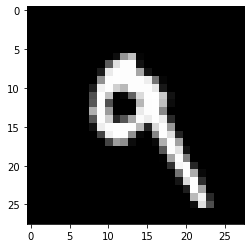

Feil ved index 9: predicted 7, fasit er9


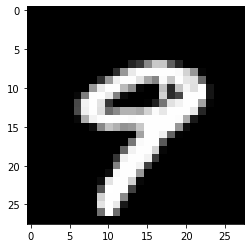

Feil ved index 16: predicted 4, fasit er9


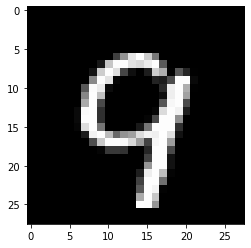

Feil ved index 18: predicted 2, fasit er3


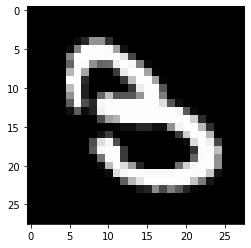

Feil ved index 22: predicted 4, fasit er6


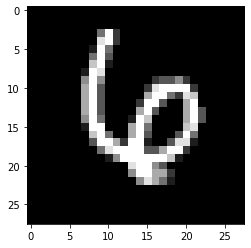

Feil ved index 25: predicted 6, fasit er0


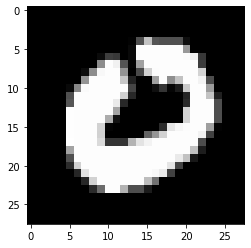

Feil ved index 46: predicted 2, fasit er1


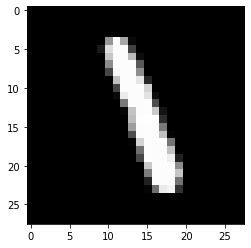

Feil ved index 54: predicted 4, fasit er6


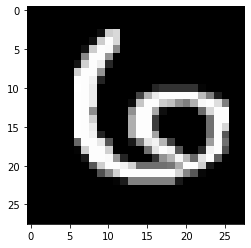

Feil ved index 65: predicted 3, fasit er4


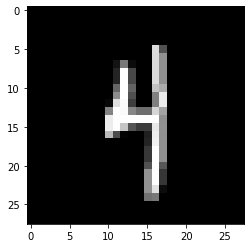

Feil ved index 73: predicted 1, fasit er9


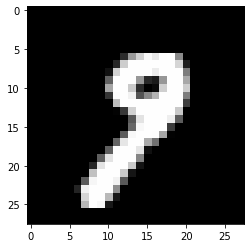

Feil ved index 78: predicted 1, fasit er9


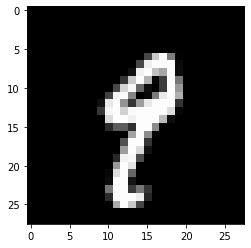

Feil ved index 88: predicted 4, fasit er6


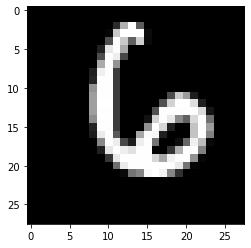

Feil ved index 92: predicted 1, fasit er9


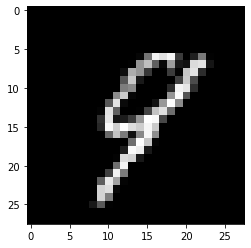

Feil ved index 96: predicted 2, fasit er1


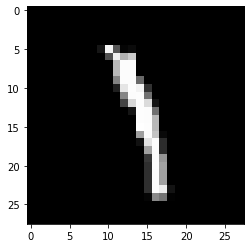

Feil ved index 97: predicted 3, fasit er7


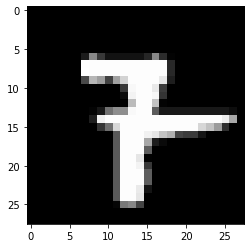

Feil ved index 100: predicted 1, fasit er6


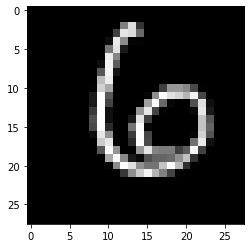

Feil ved index 102: predicted 3, fasit er5


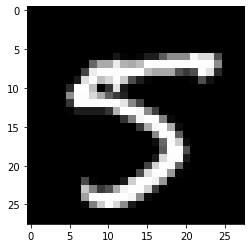

Feil ved index 104: predicted 5, fasit er9


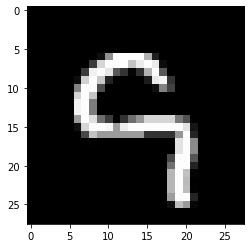

Feil ved index 111: predicted 1, fasit er7


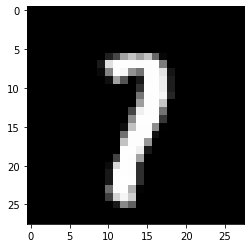

Feil ved index 114: predicted 3, fasit er7


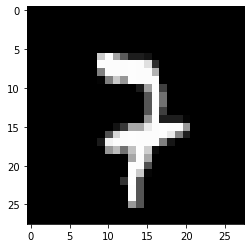

Feil ved index 118: predicted 4, fasit er9


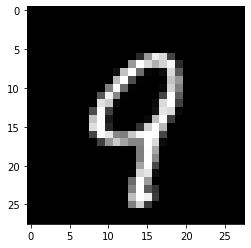

Feil ved index 125: predicted 4, fasit er9


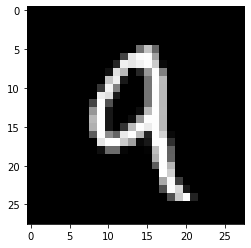

Feil ved index 133: predicted 2, fasit er7


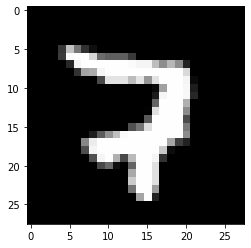

Feil ved index 134: predicted 2, fasit er8


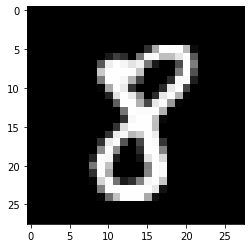

Feil ved index 135: predicted 0, fasit er1


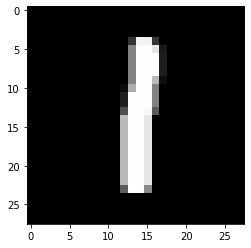

Feil ved index 137: predicted 0, fasit er1


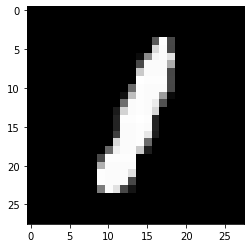

Feil ved index 138: predicted 0, fasit er6


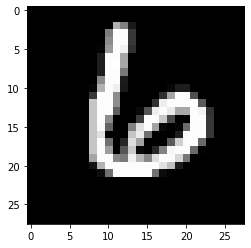

Feil ved index 139: predicted 0, fasit er4


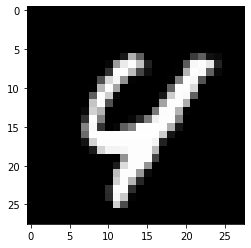

Feil ved index 140: predicted 0, fasit er6


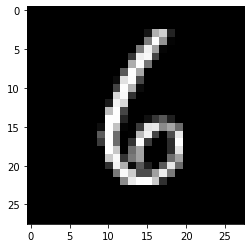

Feil ved index 141: predicted 0, fasit er7


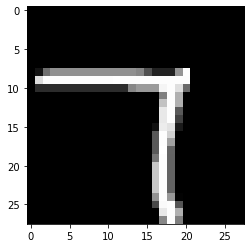

Feil ved index 142: predicted 0, fasit er3


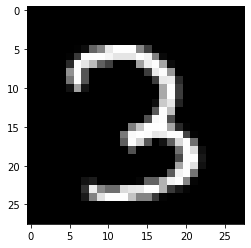

Feil ved index 143: predicted 0, fasit er1


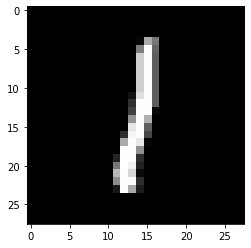

Feil ved index 144: predicted 0, fasit er7


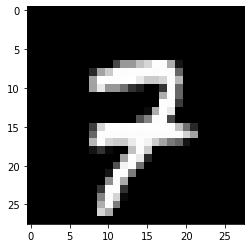

Feil ved index 145: predicted 0, fasit er1


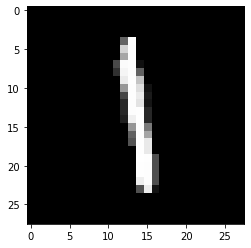

Feil ved index 146: predicted 0, fasit er8


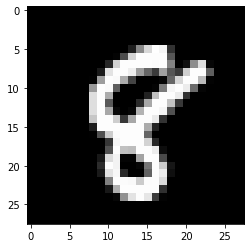

Feil ved index 147: predicted 0, fasit er2


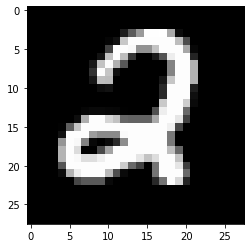

Feil ved index 149: predicted 0, fasit er2


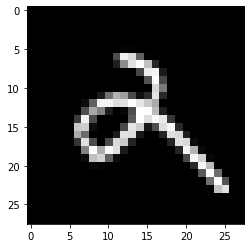

Feil ved index 150: predicted 0, fasit er9


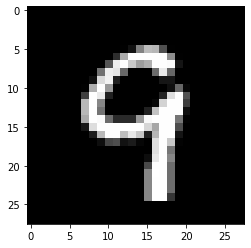

Feil ved index 151: predicted 0, fasit er9


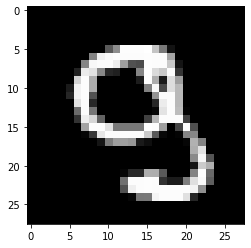

Feil ved index 152: predicted 0, fasit er5


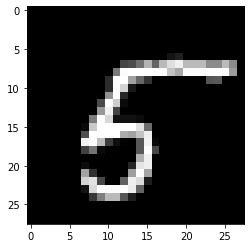

Feil ved index 153: predicted 0, fasit er5


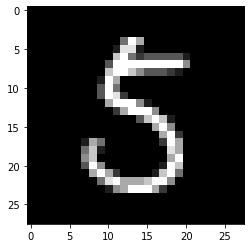

Feil ved index 154: predicted 0, fasit er1


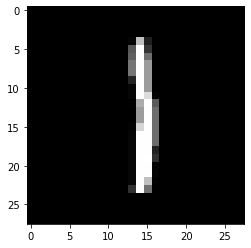

Feil ved index 155: predicted 0, fasit er5


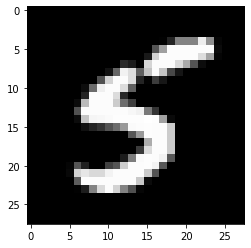

Feil ved index 156: predicted 0, fasit er6


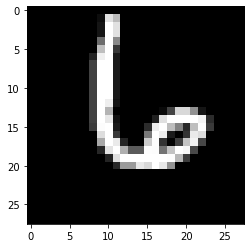

Feil ved index 158: predicted 0, fasit er3


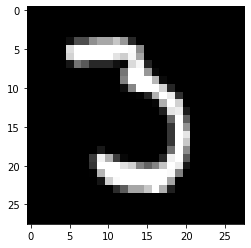

Feil ved index 159: predicted 0, fasit er4


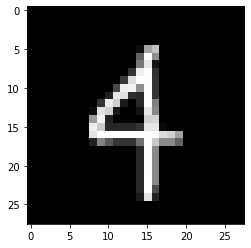

Feil ved index 160: predicted 0, fasit er4


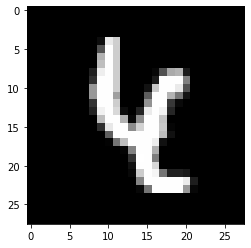

Feil ved index 161: predicted 0, fasit er6


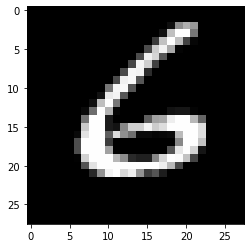

Feil ved index 162: predicted 0, fasit er5


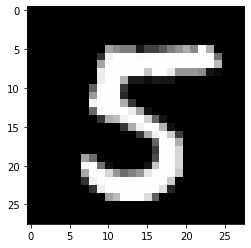

Feil ved index 163: predicted 0, fasit er4


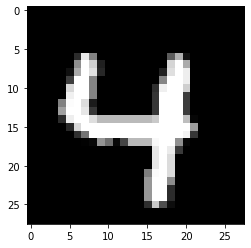

Feil ved index 164: predicted 0, fasit er6


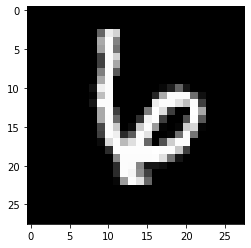

Feil ved index 165: predicted 0, fasit er5


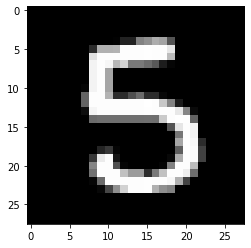

Feil ved index 166: predicted 0, fasit er4


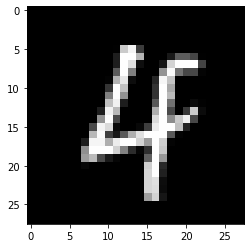

Feil ved index 167: predicted 0, fasit er5


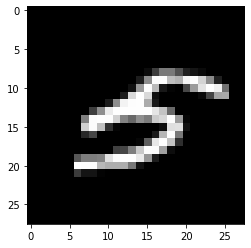

Feil ved index 168: predicted 0, fasit er1


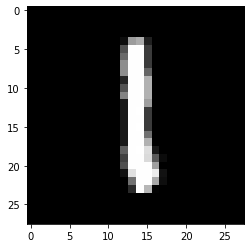

Feil ved index 169: predicted 0, fasit er4


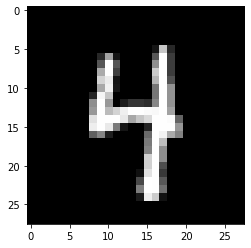

Feil ved index 170: predicted 0, fasit er4


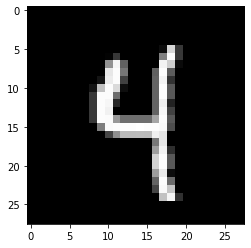

Feil ved index 171: predicted 0, fasit er7


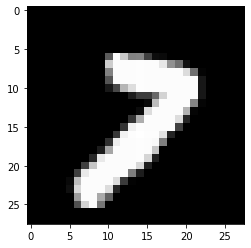

Feil ved index 172: predicted 0, fasit er2


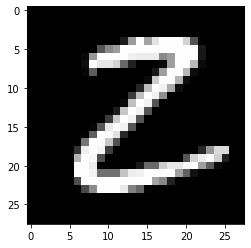

Feil ved index 173: predicted 0, fasit er3


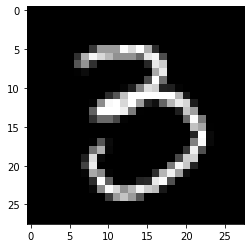

Feil ved index 174: predicted 0, fasit er2


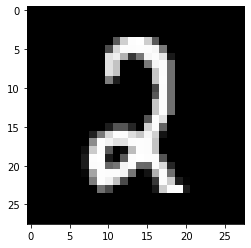

Feil ved index 175: predicted 0, fasit er7


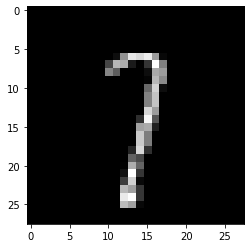

Feil ved index 176: predicted 0, fasit er1


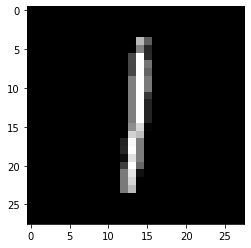

Feil ved index 177: predicted 0, fasit er8


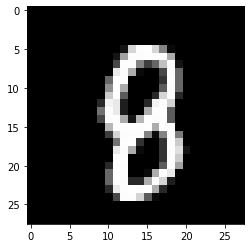

Feil ved index 178: predicted 0, fasit er1


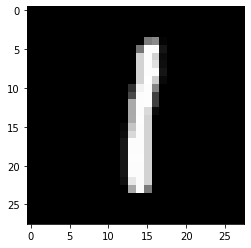

Feil ved index 179: predicted 0, fasit er8


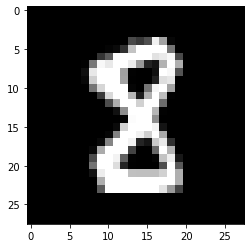

Feil ved index 180: predicted 0, fasit er1


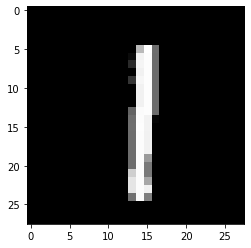

Feil ved index 181: predicted 0, fasit er8


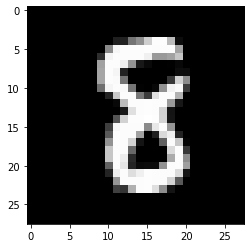

Feil ved index 182: predicted 0, fasit er5


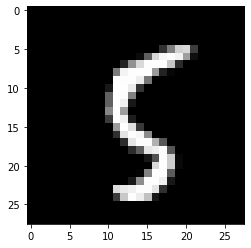

Feil ved index 184: predicted 0, fasit er8


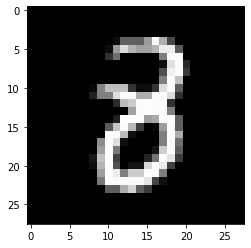

Feil ved index 185: predicted 0, fasit er9


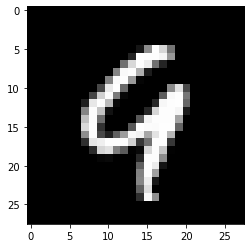

Feil ved index 186: predicted 0, fasit er2


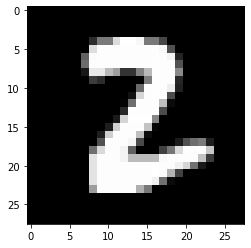

Feil ved index 187: predicted 0, fasit er5


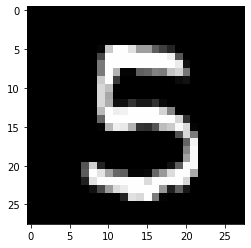

Feil ved index 189: predicted 0, fasit er1


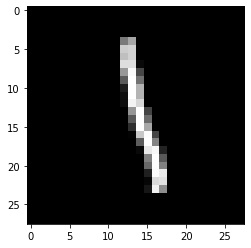

Feil ved index 190: predicted 0, fasit er1


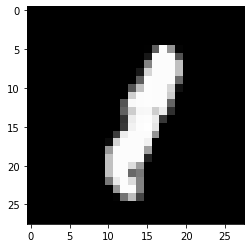

Feil ved index 191: predicted 0, fasit er1


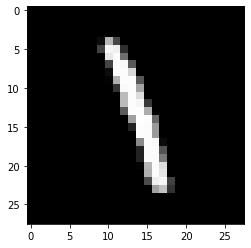

Feil ved index 193: predicted 0, fasit er9


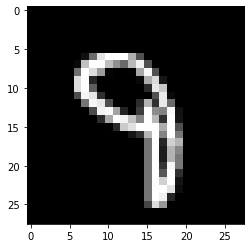

Feil ved index 195: predicted 0, fasit er3


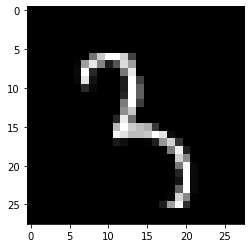

Feil ved index 196: predicted 0, fasit er1


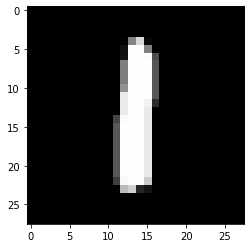

Feil ved index 197: predicted 0, fasit er6


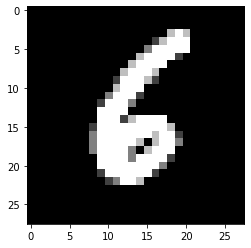

Feil ved index 198: predicted 0, fasit er4


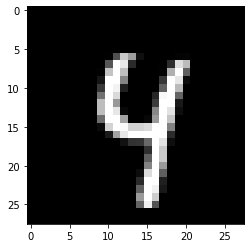

Feil ved index 199: predicted 0, fasit er2


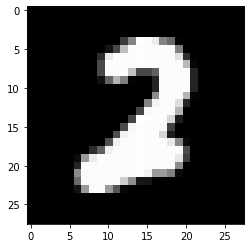

Feil ved index 200: predicted 0, fasit er3


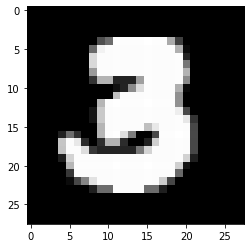

Feil ved index 201: predicted 0, fasit er6


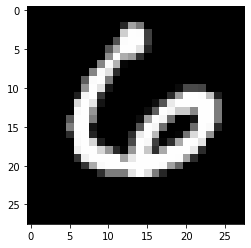

Feil ved index 202: predicted 0, fasit er1


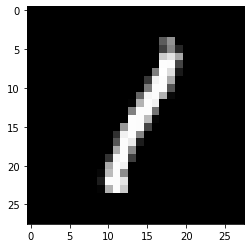

Feil ved index 203: predicted 0, fasit er1


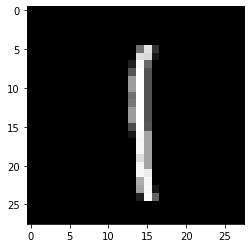

Feil ved index 204: predicted 0, fasit er1


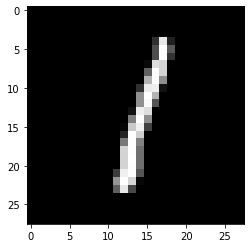

Feil ved index 205: predicted 0, fasit er3


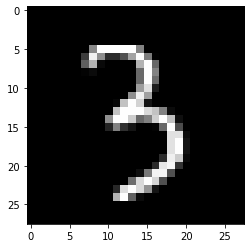

Feil ved index 206: predicted 0, fasit er9


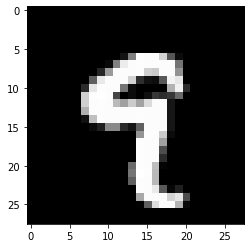

Feil ved index 207: predicted 0, fasit er5


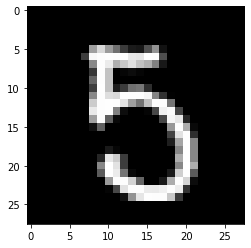

Feil ved index 208: predicted 0, fasit er2


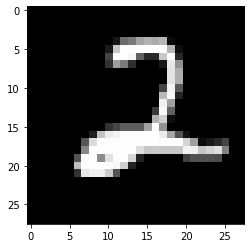

Feil ved index 209: predicted 0, fasit er9


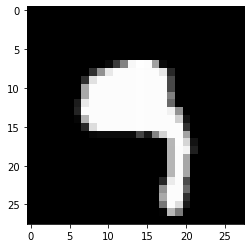

Feil ved index 210: predicted 0, fasit er4


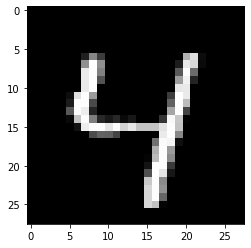

Feil ved index 211: predicted 0, fasit er5


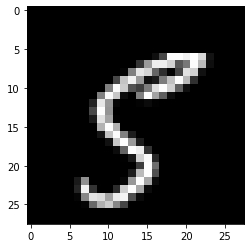

Feil ved index 212: predicted 0, fasit er9


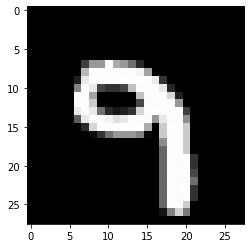

Feil ved index 213: predicted 0, fasit er3


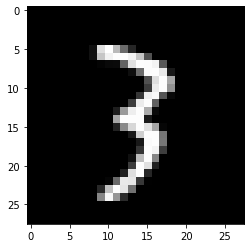

Feil ved index 214: predicted 0, fasit er9


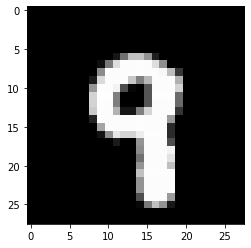

Feil ved index 216: predicted 0, fasit er3


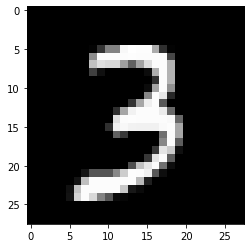

Feil ved index 217: predicted 0, fasit er6


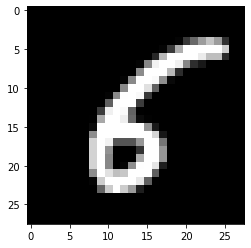

Feil ved index 218: predicted 0, fasit er5


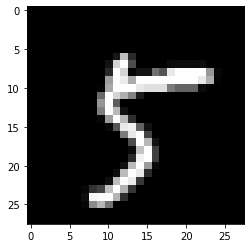

Feil ved index 219: predicted 0, fasit er5


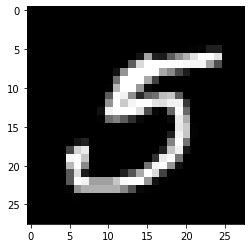

Feil ved index 220: predicted 0, fasit er7


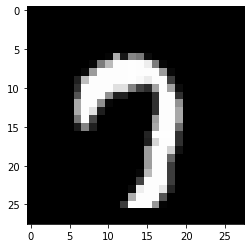

Feil ved index 221: predicted 0, fasit er2


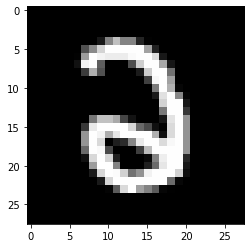

Feil ved index 222: predicted 0, fasit er2


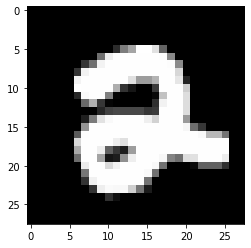

Feil ved index 223: predicted 0, fasit er7


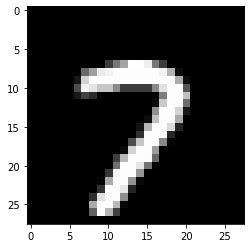

Feil ved index 224: predicted 0, fasit er1


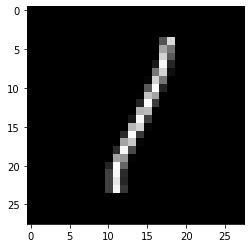

Feil ved index 225: predicted 0, fasit er2


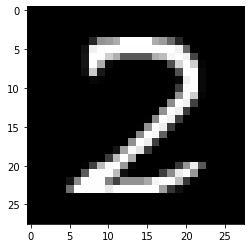

Feil ved index 226: predicted 0, fasit er8


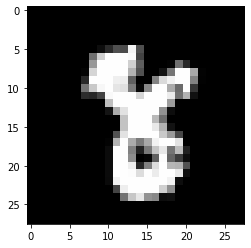

Feil ved index 227: predicted 0, fasit er4


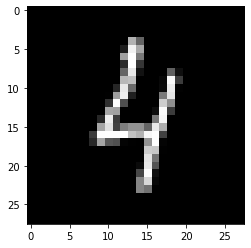

Feil ved index 228: predicted 0, fasit er1


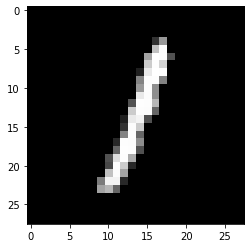

Feil ved index 229: predicted 0, fasit er7


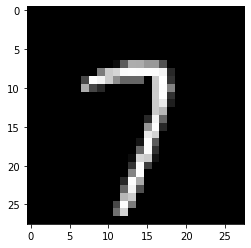

Feil ved index 230: predicted 0, fasit er3


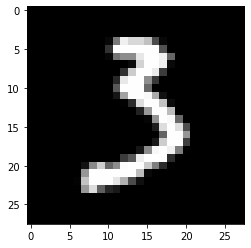

Feil ved index 231: predicted 0, fasit er3


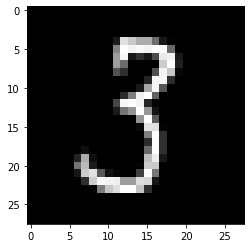

Feil ved index 232: predicted 0, fasit er8


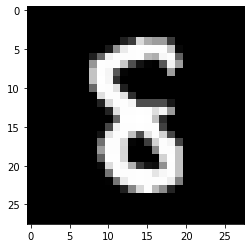

Feil ved index 233: predicted 0, fasit er8


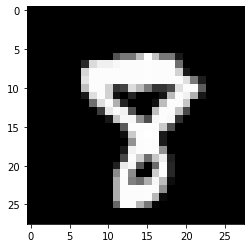

Feil ved index 234: predicted 0, fasit er7


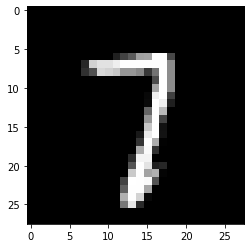

Feil ved index 235: predicted 0, fasit er9


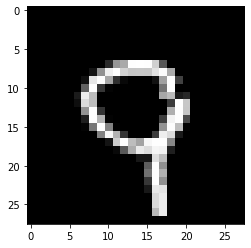

Feil ved index 236: predicted 0, fasit er2


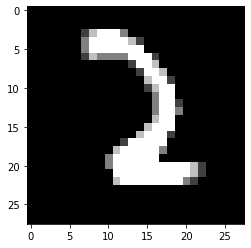

Feil ved index 237: predicted 0, fasit er2


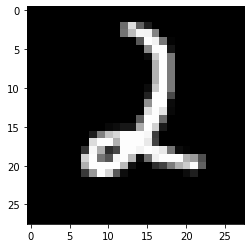

Feil ved index 238: predicted 0, fasit er4


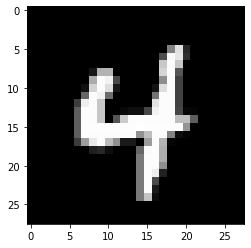

Feil ved index 239: predicted 0, fasit er1


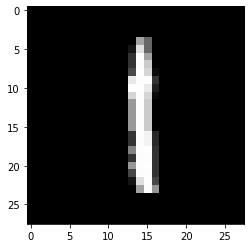

Feil ved index 240: predicted 0, fasit er5


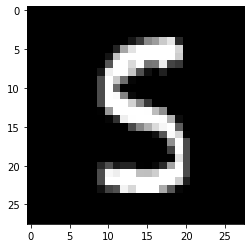

Feil ved index 241: predicted 0, fasit er9


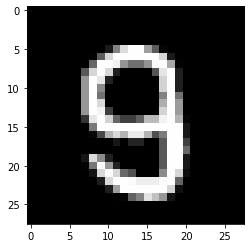

Feil ved index 242: predicted 0, fasit er8


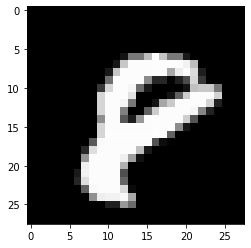

Feil ved index 243: predicted 0, fasit er7


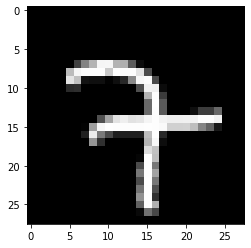

Feil ved index 244: predicted 0, fasit er2


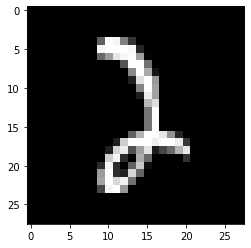

Feil ved index 245: predicted 0, fasit er3


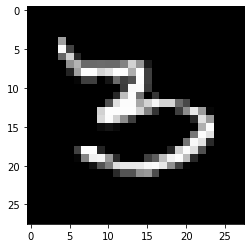

Feil ved index 247: predicted 0, fasit er4


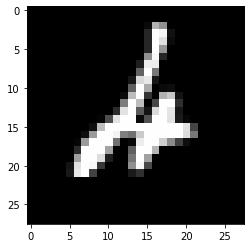

Feil ved index 248: predicted 0, fasit er4


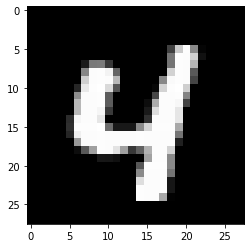

Feil ved index 249: predicted 0, fasit er2


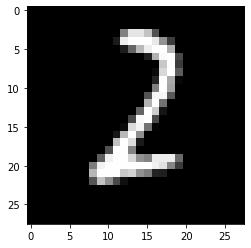

Feil ved index 250: predicted 0, fasit er4


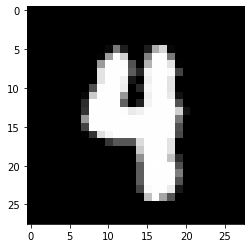

Feil ved index 251: predicted 0, fasit er1


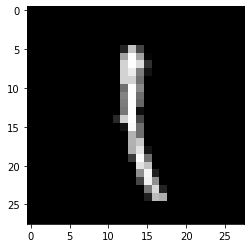

Feil ved index 252: predicted 0, fasit er9


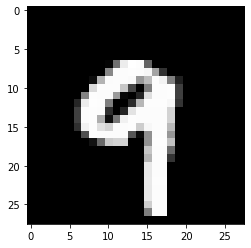

Feil ved index 253: predicted 0, fasit er5


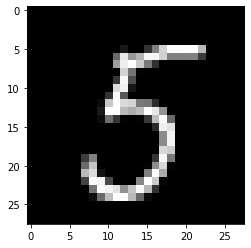

Feil ved index 254: predicted 0, fasit er7


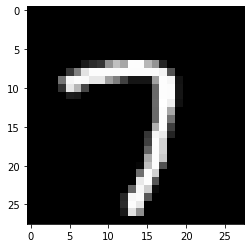

Feil ved index 255: predicted 0, fasit er7


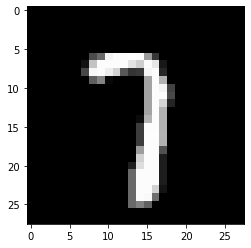

Feil ved index 256: predicted 0, fasit er2


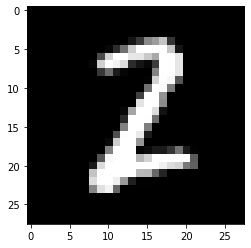

Feil ved index 257: predicted 0, fasit er8


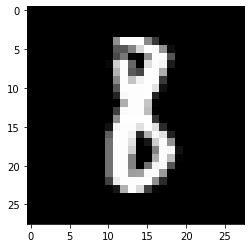

Feil ved index 258: predicted 0, fasit er2


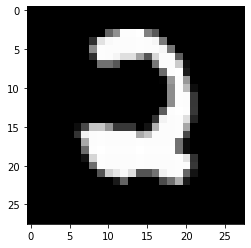

Feil ved index 259: predicted 0, fasit er6


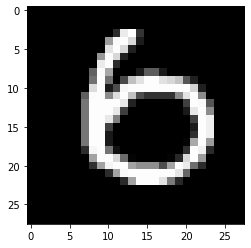

Feil ved index 260: predicted 0, fasit er8


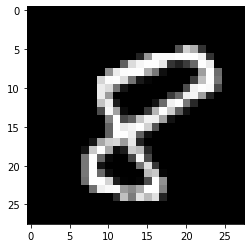

Feil ved index 261: predicted 0, fasit er5


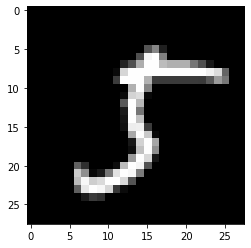

Feil ved index 262: predicted 0, fasit er7


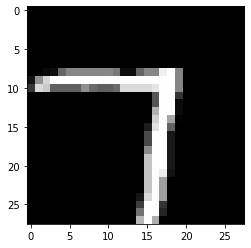

Feil ved index 263: predicted 0, fasit er7


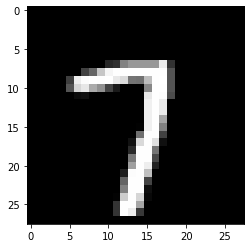

Feil ved index 264: predicted 0, fasit er9


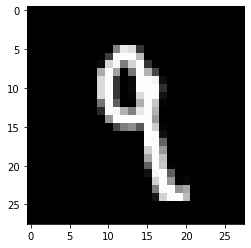

Feil ved index 265: predicted 0, fasit er1


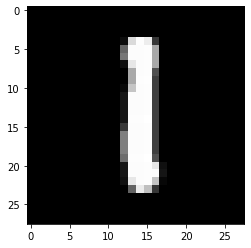

Feil ved index 266: predicted 0, fasit er8


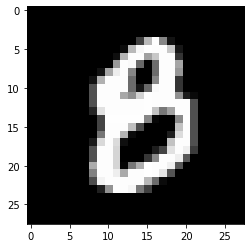

Feil ved index 267: predicted 0, fasit er1


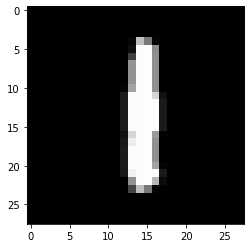

Feil ved index 268: predicted 0, fasit er8


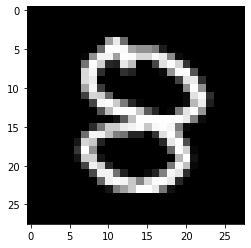

Feil ved index 270: predicted 0, fasit er3


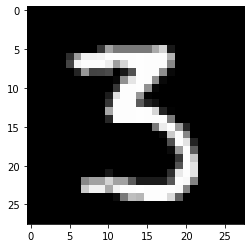

Feil ved index 272: predicted 0, fasit er1


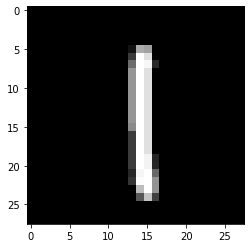

Feil ved index 273: predicted 0, fasit er9


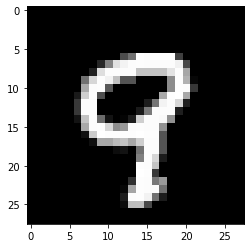

Feil ved index 274: predicted 0, fasit er9


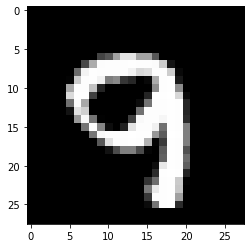

Feil ved index 275: predicted 0, fasit er4


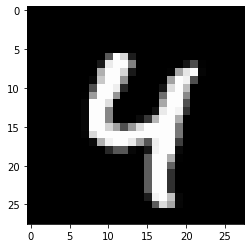

Feil ved index 276: predicted 0, fasit er1


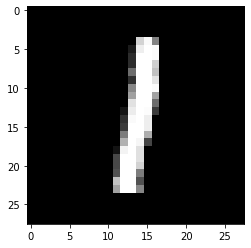

Feil ved index 277: predicted 0, fasit er8


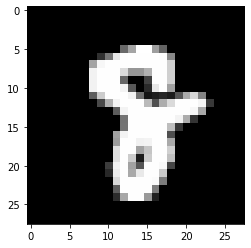

Feil ved index 278: predicted 0, fasit er2


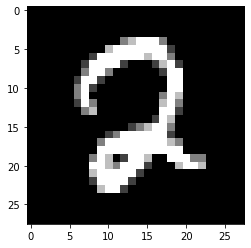

Feil ved index 279: predicted 0, fasit er1


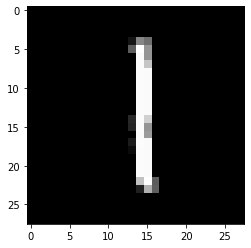

Feil ved index 280: predicted 0, fasit er2


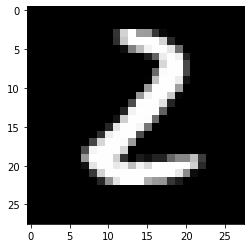

Feil ved index 281: predicted 0, fasit er9


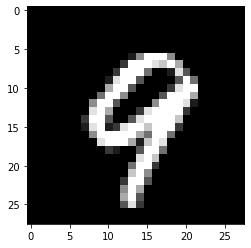

Feil ved index 282: predicted 0, fasit er7


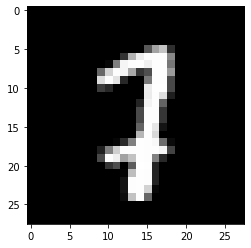

Feil ved index 283: predicted 0, fasit er5


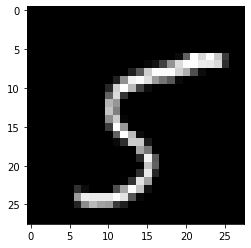

Feil ved index 284: predicted 0, fasit er9


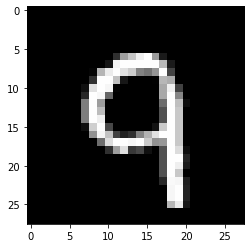

Feil ved index 285: predicted 0, fasit er2


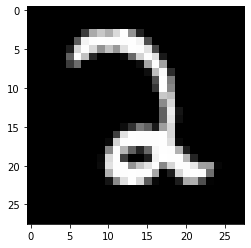

Feil ved index 286: predicted 0, fasit er6


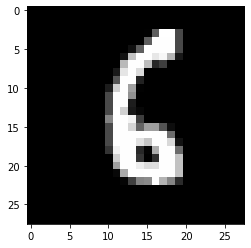

Feil ved index 287: predicted 0, fasit er4


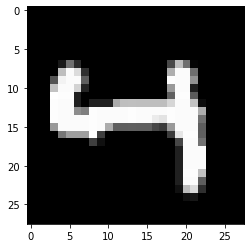

Feil ved index 288: predicted 0, fasit er1


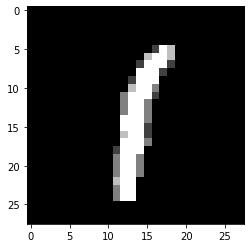

Feil ved index 289: predicted 0, fasit er5


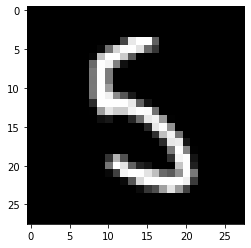

Feil ved index 290: predicted 0, fasit er8


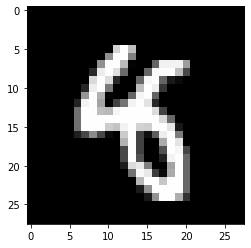

Feil ved index 291: predicted 0, fasit er2


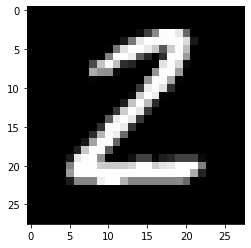

Feil ved index 292: predicted 0, fasit er9


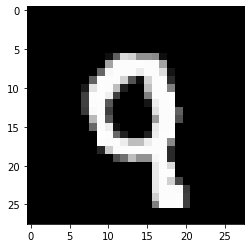

Feil ved index 293: predicted 0, fasit er2


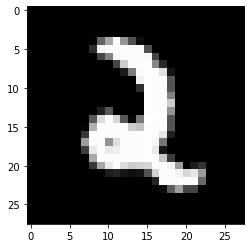

Feil ved index 295: predicted 0, fasit er4


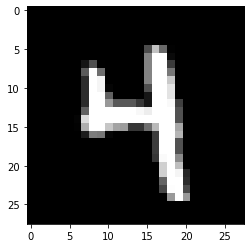

Feil ved index 298: predicted 0, fasit er2


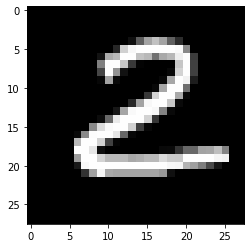

Feil ved index 299: predicted 0, fasit er8


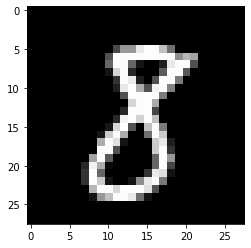

In [9]:
import matplotlib.pyplot as plt
print(yt)
print(yp)

for i,fasit in enumerate(yt):
    if fasit != yp[i]:
        print(f"Feil ved index {i}: predicted {yp[i]}, fasit er{fasit}")
        plt.imshow(x_test[i], cmap='grey')
        plt.show()